# Teen Smartphone Usage and Addiction Classification Project

## Importing Necessary Libraries

In [54]:
# Importing libraries for data analysis, visualization, and modeling
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [55]:
# Loading dataset from CSV
df = pd.read_csv('teen_phone_addiction_dataset.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (3000, 25)


## Basic Data Inspection

In [56]:
# Column Names
df.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Addiction_Level'],
      dtype='object')

In [57]:
# Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [58]:
# Statistical Summary
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [59]:
# First 5 rows
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [60]:
# Checking for null values
df.isnull().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

In [61]:
# Checking for duplicates
df.duplicated().sum()

0

## Data Cleaning and Preprocessing

In [62]:
# Dropping non-predictive identifiers
df_clean = df.drop(columns=['ID', 'Name', 'Location'], errors='ignore')
print(f"Shape after dropping identifiers: {df_clean.shape}")

Shape after dropping identifiers: (3000, 22)


In [63]:
# Scanning for negative values in time-related columns
time_cols = [
    'Daily_Usage_Hours', 'Sleep_Hours', 'Exercise_Hours', 'Screen_Time_Before_Bed', 
    'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Weekend_Usage_Hours'
]
negative_counts = (df_clean[time_cols] < 0).sum()
print("Negative value counts:")
print(negative_counts)

Negative value counts:
Daily_Usage_Hours         0
Sleep_Hours               0
Exercise_Hours            0
Screen_Time_Before_Bed    0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Weekend_Usage_Hours       0
dtype: int64


In [64]:
# Checking for extreme outliers in usage and sleep hours
print(f"Daily usage max: {df_clean['Daily_Usage_Hours'].max()} hours")
print(f"Sleep hours max: {df_clean['Sleep_Hours'].max()} hours")
print(f"Weekend usage max: {df_clean['Weekend_Usage_Hours'].max()} hours")

Daily usage max: 11.5 hours
Sleep hours max: 10.0 hours
Weekend usage max: 14.0 hours


In [65]:
# Validating feature data types
print("Feature data types:")
print(df_clean.dtypes)

Feature data types:
Age                         int64
Gender                     object
School_Grade               object
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
Phone_Checks_Per_Day        int64
Apps_Used_Daily             int64
Time_on_Social_Media      float64
Time_on_Gaming            float64
Time_on_Education         float64
Phone_Usage_Purpose        object
Family_Communication        int64
Weekend_Usage_Hours       float64
Addiction_Level           float64
dtype: object


In [66]:
# Defining binning logic for target variable
# Low: 0 (Addiction_Level < 4.0)
# Medium: 1 (Addiction_Level 4.0 to 7.0)
# High: 2 (Addiction_Level > 7.0)
def bin_addiction(level):
    if level < 4.0:
        return 0
    elif level <= 7.0:
        return 1
    else:
        return 2

In [67]:
# Applying binning to target variable
df_clean['Addiction_Level_Binned'] = df_clean['Addiction_Level'].apply(bin_addiction)
print("Class distribution of the binned target:")
print(df_clean['Addiction_Level_Binned'].value_counts())

Class distribution of the binned target:
Addiction_Level_Binned
2    2554
1     405
0      41
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### How does the distribution of daily usage hours shift across different school grades?

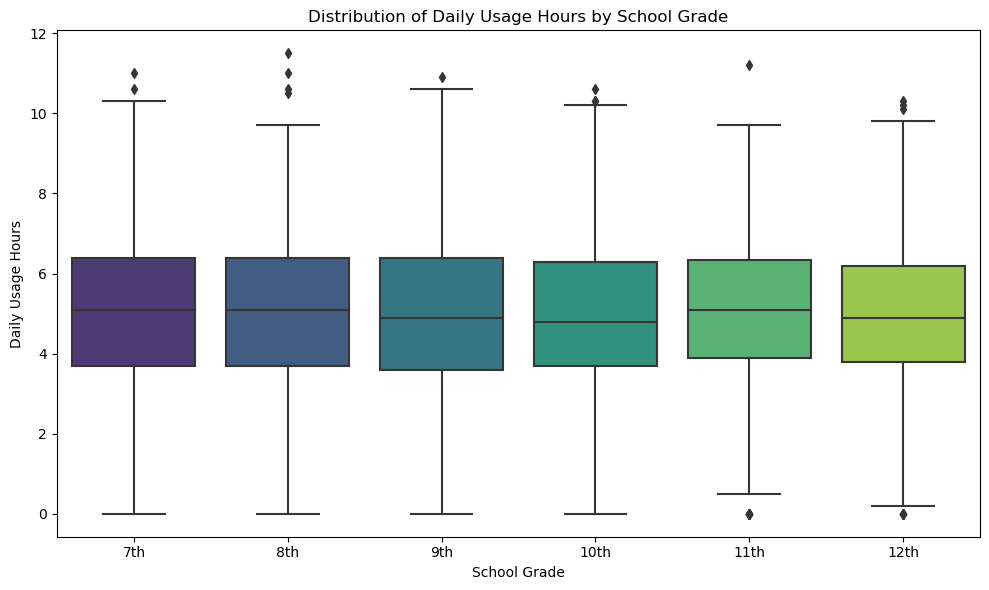

In [68]:
# Plotting daily usage across school grades
plt.figure(figsize=(10, 6))
grade_order = ['7th', '8th', '9th', '10th', '11th', '12th']
sns.boxplot(
    data=df_clean, 
    x='School_Grade', 
    y='Daily_Usage_Hours', 
    order=grade_order, 
    palette='viridis'
)
plt.title('Distribution of Daily Usage Hours by School Grade')
plt.xlabel('School Grade')
plt.ylabel('Daily Usage Hours')
plt.tight_layout()
plt.savefig('plots/eda_q1_grade_usage.png', dpi=300)
plt.show()

In [69]:
# Calculating and displaying mean usage hours per grade
mean_usage_grade = df_clean.groupby('School_Grade')['Daily_Usage_Hours'].mean().reindex(grade_order)
print("Mean daily usage hours per grade:")
print(mean_usage_grade)

Mean daily usage hours per grade:
School_Grade
7th     5.077062
8th     5.066390
9th     5.012167
10th    4.977618
11th    5.061795
12th    4.936862
Name: Daily_Usage_Hours, dtype: float64


### What is the exact correlation between screen time before bed and self-reported sleep hours?

In [70]:
# Calculating correlation coefficients between screen time and sleep hours
pearson_corr = df_clean['Screen_Time_Before_Bed'].corr(df_clean['Sleep_Hours'], method='pearson')
spearman_corr = df_clean['Screen_Time_Before_Bed'].corr(df_clean['Sleep_Hours'], method='spearman')
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

Pearson correlation: -0.0043
Spearman correlation: -0.0035


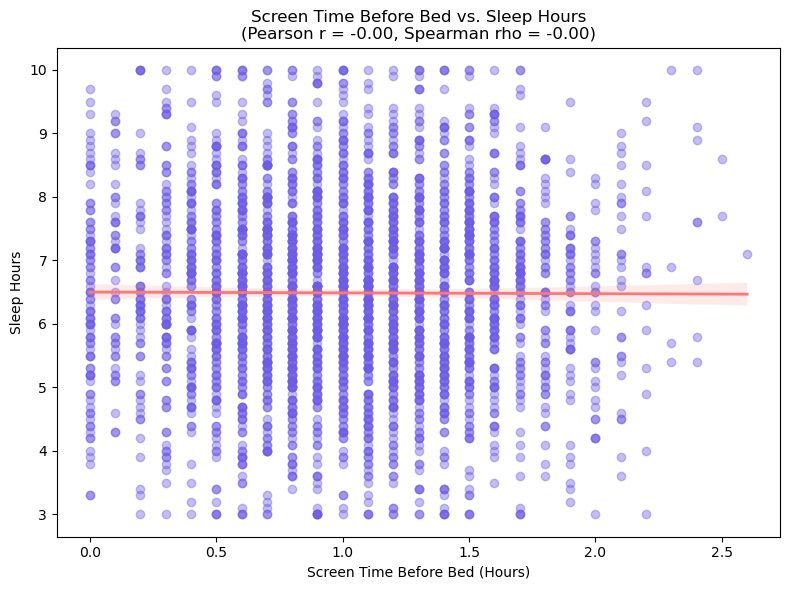

In [71]:
# Visualizing screen time before bed versus sleep hours
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_clean, 
    x='Screen_Time_Before_Bed', 
    y='Sleep_Hours', 
    scatter_kws={'alpha': 0.4, 'color': '#6c5ce7'}, 
    line_kws={'color': '#ff7675', 'linewidth': 2}
)
plt.title(f'Screen Time Before Bed vs. Sleep Hours\n(Pearson r = {pearson_corr:.2f}, Spearman rho = {spearman_corr:.2f})')
plt.xlabel('Screen Time Before Bed (Hours)')
plt.ylabel('Sleep Hours')
plt.tight_layout()
plt.savefig('plots/eda_q2_screentime_sleep.png', dpi=300)
plt.show()

### Are teenagers using phones primarily for gaming experiencing higher average anxiety levels than those using them for education?

In [72]:
# Filtering anxiety data for gaming and education purposes
gaming_anxiety = df_clean[df_clean['Phone_Usage_Purpose'] == 'Gaming']['Anxiety_Level']
education_anxiety = df_clean[df_clean['Phone_Usage_Purpose'] == 'Education']['Anxiety_Level']
print(f"Gaming anxiety mean: {gaming_anxiety.mean():.2f}")
print(f"Education anxiety mean: {education_anxiety.mean():.2f}")

Gaming anxiety mean: 5.40
Education anxiety mean: 5.84


In [73]:
# Running independent t-test for anxiety levels
t_stat, p_val = stats.ttest_ind(gaming_anxiety, education_anxiety, equal_var=False)
print(f"T-test statistic: {t_stat:.4f}, p-value: {p_val:.4g}")

T-test statistic: -2.6334, p-value: 0.008566


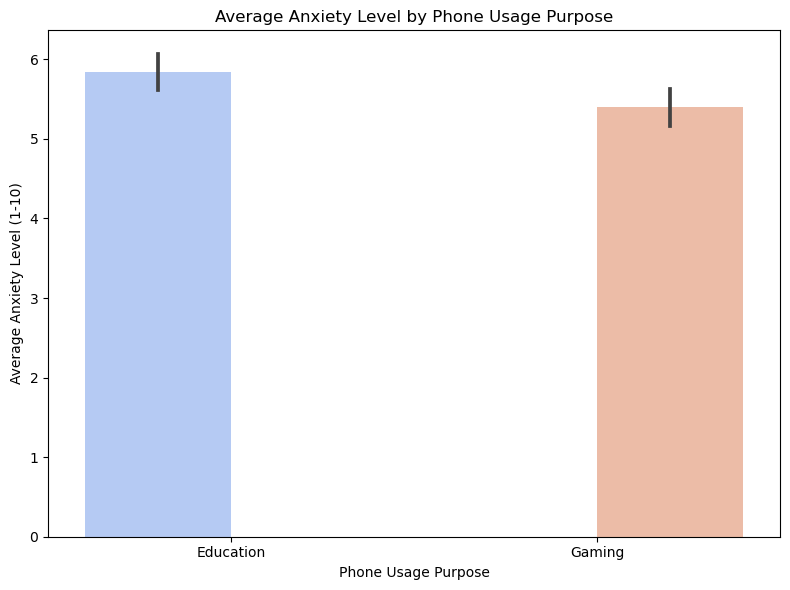

In [74]:
# Comparing anxiety levels by usage purpose
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_clean[df_clean['Phone_Usage_Purpose'].isin(['Gaming', 'Education'])],
    x='Phone_Usage_Purpose',
    y='Anxiety_Level',
    palette='coolwarm',
    hue='Phone_Usage_Purpose',
    errorbar='ci'
)
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.title('Average Anxiety Level by Phone Usage Purpose')
plt.xlabel('Phone Usage Purpose')
plt.ylabel('Average Anxiety Level (1-10)')
plt.tight_layout()
plt.savefig('plots/eda_q3_purpose_anxiety.png', dpi=300)
plt.show()

### How do daily phone checks vary by gender across different levels of family communication?

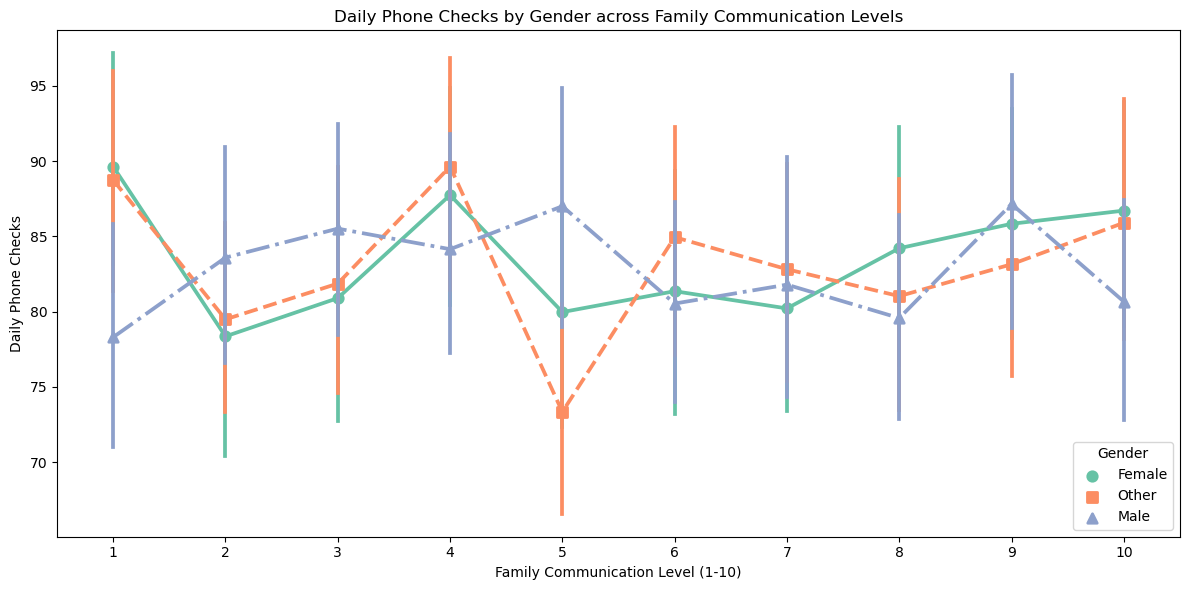

In [75]:
# Visualizing daily checks across family communication by gender
plt.figure(figsize=(12, 6))
sns.pointplot(
    data=df_clean,
    x='Family_Communication',
    y='Phone_Checks_Per_Day',
    hue='Gender',
    palette='Set2',
    markers=['o', 's', '^'],
    linestyles=['-', '--', '-.']
)
plt.title('Daily Phone Checks by Gender across Family Communication Levels')
plt.xlabel('Family Communication Level (1-10)')
plt.ylabel('Daily Phone Checks')
plt.tight_layout()
plt.savefig('plots/eda_q4_gender_family.png', dpi=300)
plt.show()

### Is there a visible tipping point where time spent on social media begins to drastically degrade academic performance?

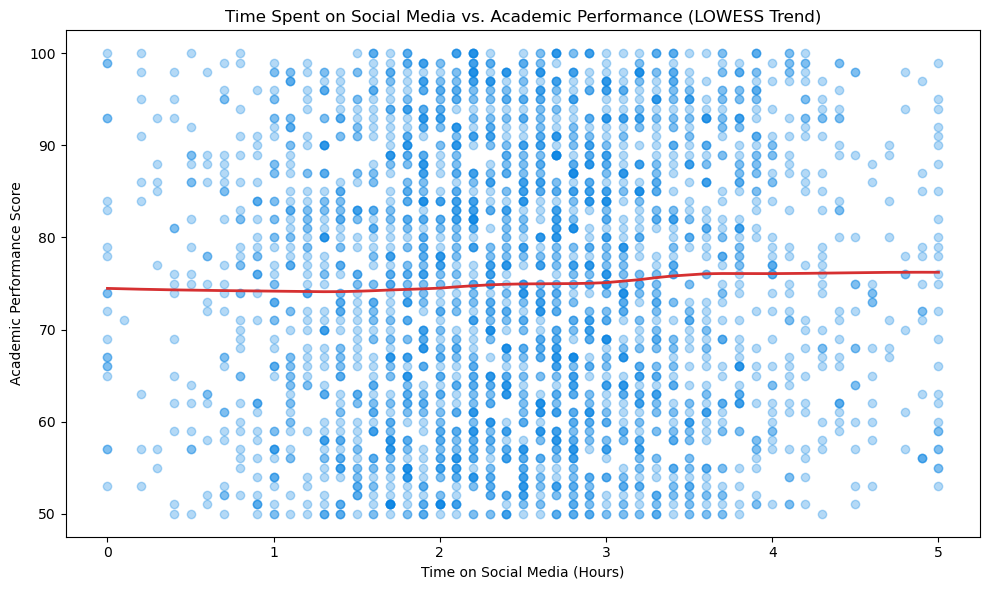

In [76]:
# Investigating social media time versus academic performance
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_clean,
    x='Time_on_Social_Media',
    y='Academic_Performance',
    scatter_kws={'alpha': 0.3, 'color': '#0984e3'},
    line_kws={'color': '#d63031', 'linewidth': 2},
    lowess=True
)
plt.title('Time Spent on Social Media vs. Academic Performance (LOWESS Trend)')
plt.xlabel('Time on Social Media (Hours)')
plt.ylabel('Academic Performance Score')
plt.tight_layout()
plt.savefig('plots/eda_q5_social_academic.png', dpi=300)
plt.show()

### How does weekly exercise duration correlate with depression levels and overall self-esteem scores?

In [77]:
# Calculating correlation matrix for exercise, depression, and self-esteem
exercise_corr_cols = ['Exercise_Hours', 'Depression_Level', 'Self_Esteem']
corr_matrix = df_clean[exercise_corr_cols].corr()
print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
                  Exercise_Hours  Depression_Level  Self_Esteem
Exercise_Hours           1.00000         -0.011770    -0.014320
Depression_Level        -0.01177          1.000000    -0.026647
Self_Esteem             -0.01432         -0.026647     1.000000


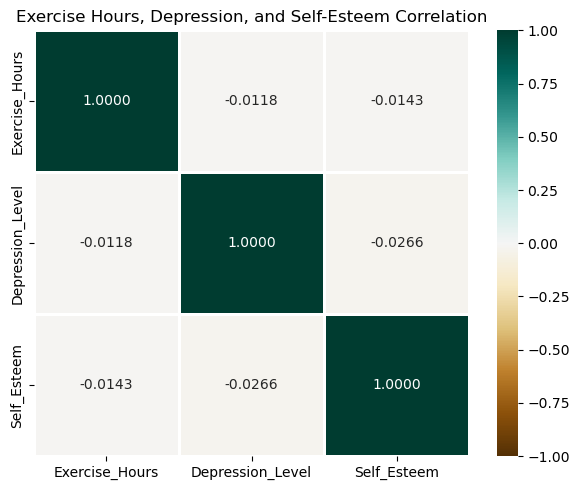

In [78]:
# Plotting exercise correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1,
    fmt=".4f",
    linewidths=1
)
plt.title('Exercise Hours, Depression, and Self-Esteem Correlation')
plt.tight_layout()
plt.savefig('plots/eda_q6_exercise_correlation.png', dpi=300)
plt.show()

### Do parental control settings show a statistically significant reduction in weekend usage hours compared to weekdays?

In [79]:
# Computing usage averages under parental control settings
pc_active = df_clean[df_clean['Parental_Control'] == 1]
pc_inactive = df_clean[df_clean['Parental_Control'] == 0]

print("Mean usage for kids with Parental Control:")
print(f"Weekday Daily Usage: {pc_active['Daily_Usage_Hours'].mean():.2f} hours")
print(f"Weekend Usage: {pc_active['Weekend_Usage_Hours'].mean():.2f} hours")

print("\nMean usage for kids without Parental Control:")
print(f"Weekday Daily Usage: {pc_inactive['Daily_Usage_Hours'].mean():.2f} hours")
print(f"Weekend Usage: {pc_inactive['Weekend_Usage_Hours'].mean():.2f} hours")

Mean usage for kids with Parental Control:
Weekday Daily Usage: 5.02 hours
Weekend Usage: 6.02 hours

Mean usage for kids without Parental Control:
Weekday Daily Usage: 5.02 hours
Weekend Usage: 6.01 hours


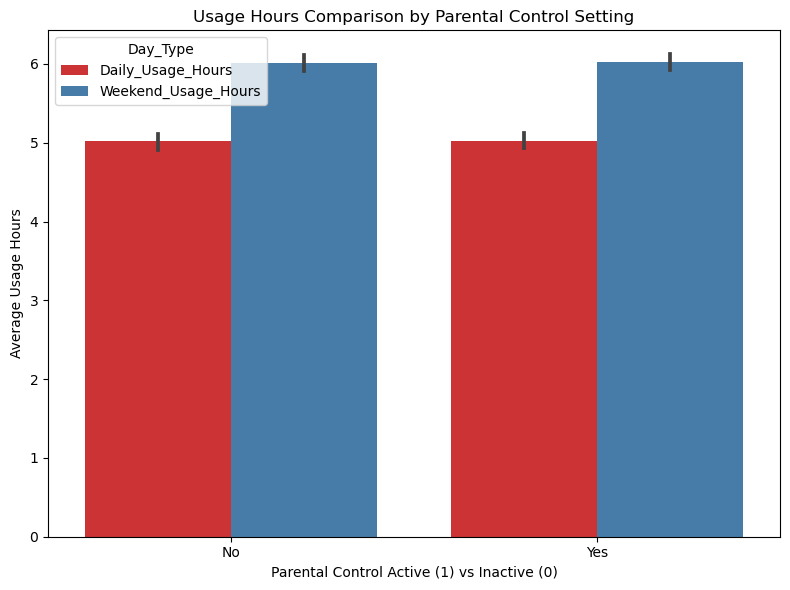

In [80]:
# Visualizing usage hours comparison by parental control
df_melted = df_clean.melt(
    id_vars=['Parental_Control'], 
    value_vars=['Daily_Usage_Hours', 'Weekend_Usage_Hours'],
    var_name='Day_Type', 
    value_name='Usage_Hours'
)
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_melted,
    x='Parental_Control',
    y='Usage_Hours',
    hue='Day_Type',
    palette='Set1'
)
plt.title('Usage Hours Comparison by Parental Control Setting')
plt.xlabel('Parental Control Active (1) vs Inactive (0)')
plt.ylabel('Average Usage Hours')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.savefig('plots/eda_q7_parental_control_usage.png', dpi=300)
plt.show()

### What is the multivariate interaction between apps used daily, daily usage hours, and the final binned addiction level?

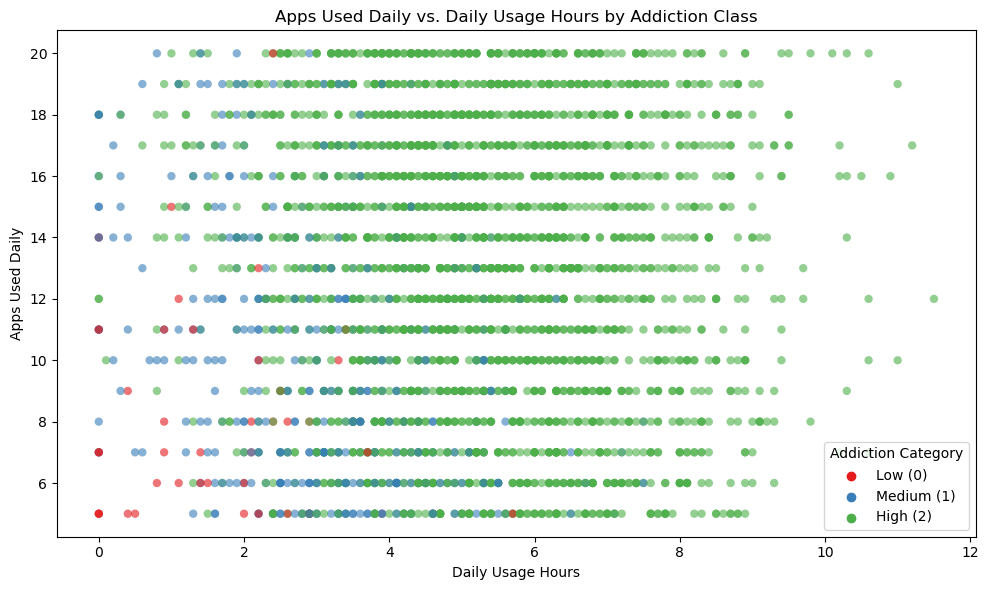

In [81]:
# Plotting apps used daily versus usage hours by addiction class
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='Daily_Usage_Hours',
    y='Apps_Used_Daily',
    hue='Addiction_Level_Binned',
    palette='Set1',
    alpha=0.6,
    edgecolor='none'
)
plt.title('Apps Used Daily vs. Daily Usage Hours by Addiction Class')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Apps Used Daily')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Low (0)', 'Medium (1)', 'High (2)'], title='Addiction Category')
plt.tight_layout()
plt.savefig('plots/eda_q8_multivariate_interaction.png', dpi=300)
plt.show()

### Are highly addicted individuals showing a disproportionate drop in face-to-face social interactions?

In [82]:
# Grouping by addiction category to calculate mean social interactions
mean_social = df_clean.groupby('Addiction_Level_Binned')['Social_Interactions'].mean()
print("Mean social interactions across addiction levels:")
print(mean_social)

Mean social interactions across addiction levels:
Addiction_Level_Binned
0    4.707317
1    5.219753
2    5.084573
Name: Social_Interactions, dtype: float64


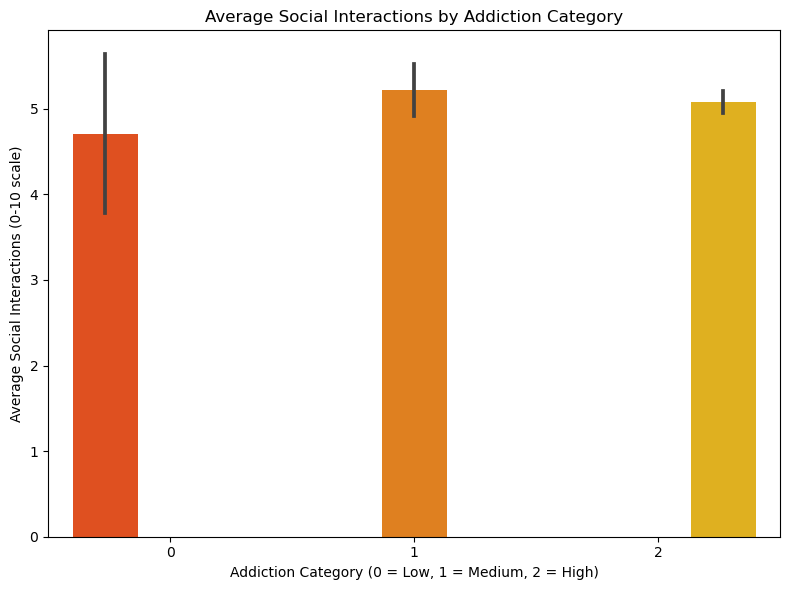

In [83]:
# Comparing face-to-face social interactions across addiction levels
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_clean,
    x='Addiction_Level_Binned',
    y='Social_Interactions',
    palette='autumn',
    hue='Addiction_Level_Binned'
)
if ax.get_legend() is not None:
    ax.get_legend().remove()
plt.title('Average Social Interactions by Addiction Category')
plt.xlabel('Addiction Category (0 = Low, 1 = Medium, 2 = High)')
plt.ylabel('Average Social Interactions (0-10 scale)')
plt.tight_layout()
plt.savefig('plots/eda_q9_social_interactions.png', dpi=300)
plt.show()

### Which specific features reveal the highest linear and non-linear correlation with the target addiction scale?

In [84]:
# Selecting numerical features for correlation analysis
num_features = df_clean.select_dtypes(include=[np.number]).columns
num_features = [col for col in num_features if col not in ['Addiction_Level', 'Addiction_Level_Binned']]

In [85]:
# Computing Pearson correlations with addiction scale
pearson_corrs = df_clean[num_features].apply(lambda x: x.corr(df_clean['Addiction_Level']))
print("Pearson correlations with Addiction_Level:")
print(pearson_corrs.sort_values(ascending=False))

Pearson correlations with Addiction_Level:
Daily_Usage_Hours         0.600771
Apps_Used_Daily           0.319287
Time_on_Social_Media      0.306578
Time_on_Gaming            0.273060
Phone_Checks_Per_Day      0.246342
Age                       0.031306
Anxiety_Level             0.016005
Screen_Time_Before_Bed    0.013784
Academic_Performance      0.012264
Depression_Level          0.008491
Time_on_Education        -0.000586
Parental_Control         -0.001016
Family_Communication     -0.010482
Social_Interactions      -0.010631
Weekend_Usage_Hours      -0.013049
Exercise_Hours           -0.021015
Self_Esteem              -0.022292
Sleep_Hours              -0.216681
dtype: float64


In [86]:
# Calculating Mutual Information scores for non-linear correlation
X_num = df_clean[num_features].fillna(df_clean[num_features].median())
y_cont = df_clean['Addiction_Level']
mi_scores = mutual_info_classif(X_num, df_clean['Addiction_Level_Binned'], random_state=42)
mi_series = pd.Series(mi_scores, index=num_features)
print("\nMutual Information scores with binned Addiction_Level:")
print(mi_series.sort_values(ascending=False))


Mutual Information scores with binned Addiction_Level:
Daily_Usage_Hours         0.116402
Apps_Used_Daily           0.030174
Time_on_Gaming            0.029678
Sleep_Hours               0.028533
Time_on_Social_Media      0.026924
Phone_Checks_Per_Day      0.013000
Academic_Performance      0.009733
Anxiety_Level             0.007508
Exercise_Hours            0.004130
Depression_Level          0.003624
Weekend_Usage_Hours       0.003135
Parental_Control          0.002300
Screen_Time_Before_Bed    0.000000
Self_Esteem               0.000000
Social_Interactions       0.000000
Time_on_Education         0.000000
Family_Communication      0.000000
Age                       0.000000
dtype: float64


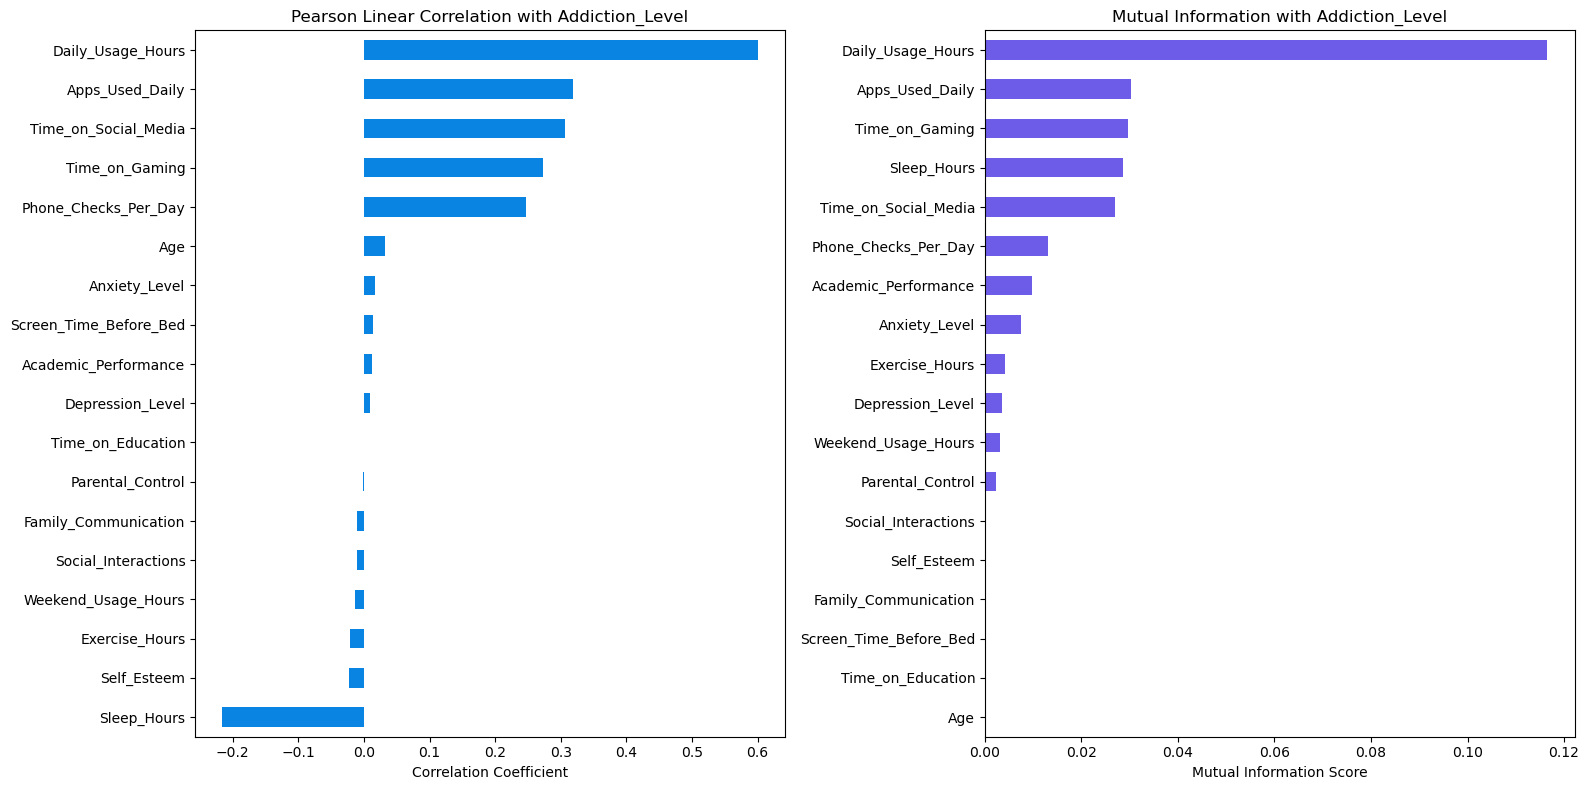

In [87]:
# Visualizing linear and non-linear correlations side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pearson plot
pearson_corrs.sort_values().plot(kind='barh', ax=axes[0], color='#0984e3')
axes[0].set_title('Pearson Linear Correlation with Addiction_Level')
axes[0].set_xlabel('Correlation Coefficient')

# Mutual Information plot
mi_series.sort_values().plot(kind='barh', ax=axes[1], color='#6c5ce7')
axes[1].set_title('Mutual Information with Addiction_Level')
axes[1].set_xlabel('Mutual Information Score')

plt.tight_layout()
plt.savefig('plots/eda_q10_correlations.png', dpi=300)
plt.show()

## Feature Selection

In [88]:
# Separating feature matrix X and target y
X = df_clean.drop(columns=['Addiction_Level', 'Addiction_Level_Binned'])
y = df_clean['Addiction_Level_Binned']

## Train Test Split

In [89]:
# Splitting dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Training features size: {X_train.shape}")
print(f"Test features size: {X_test.shape}")

Training features size: (2400, 21)
Test features size: (600, 21)


In [90]:
# Applying SMOTE to address class imbalance
smote = SMOTE(
    sampling_strategy='not majority',
    random_state=42,
    k_neighbors=3
)

## Scaling and Encoding

In [91]:
# Defining column lists by data type
cat_cols = ['Gender', 'School_Grade', 'Phone_Usage_Purpose']
num_cols = [col for col in X.columns if col not in cat_cols]

In [92]:
# Building Preprocessing Pipeline A with feature scaling
preprocessor_a = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

In [93]:
# Building Preprocessing Pipeline B without feature scaling
preprocessor_b = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

## Model Training, Tuning, & Comparative Analysis

In [94]:
# Defining model configurations and grid search parameters with class balancing
models_config = {
    'Logistic Regression': {
        # Added class_weight='balanced'
        'classifier': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'preprocessor': preprocessor_a,
        'param_grid': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0],
            'classifier__penalty': ['l2']
        }
    },
    'SVM': {
        # Added class_weight='balanced'
        'classifier': SVC(random_state=42, probability=True, class_weight='balanced'),
        'preprocessor': preprocessor_a,
        'param_grid': {
            'classifier__C': [0.1, 1.0, 10.0],
            'classifier__kernel': ['rbf', 'linear']
        }
    },
    'KNN': {
        # KNN does not have a built-in class_weight parameter. 
        # Setting weights='distance' in the grid search helps penalize based on proximity, 
        # which can mitigate some imbalance issues.
        'classifier': KNeighborsClassifier(metric='cosine'),
        'preprocessor': preprocessor_a,
        'param_grid': {
            'classifier__n_neighbors': [3, 5, 7, 9],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    'Decision Tree': {
        # Added class_weight='balanced'
        'classifier': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'preprocessor': preprocessor_b,
        'param_grid': {
            'classifier__max_depth': [None, 5, 10, 15],
            'classifier__min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        # Added class_weight='balanced' 
        # (Alternatively, you can try 'balanced_subsample' for Random Forests)
        'classifier': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'preprocessor': preprocessor_b,
        'param_grid': {
            'classifier__n_estimators': [50, 100, 150],
            'classifier__max_depth': [None, 5, 10]
        }
    },
    'XGBoost': {
        # XGBoost handles multi-class imbalance best by evaluating class distribution weights during the .fit() step,
        # or by optimizing the evaluation metric directly using 'mlogloss'.
        'classifier': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        'preprocessor': preprocessor_b,
        'param_grid': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.05, 0.1, 0.2],
            'classifier__max_depth': [3, 5, 7]
        }
    }
}

In [95]:
# Initializing output storage
results_dict = {}
best_estimators = {}

In [96]:
# Training and tuning Logistic Regression
name = 'Logistic Regression'
config = models_config[name]
pipeline = Pipeline(steps=[('preprocessor', config['preprocessor']),
        ('smote', smote),
        ('classifier', config['classifier'])])

grid_search = GridSearchCV(estimator=pipeline, param_grid=config['param_grid'], cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_estimators[name] = best_model
y_pred = best_model.predict(X_test)
results_dict[name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted'),
    'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro')
}
print(f"{name} best params: {grid_search.best_params_}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Logistic Regression best params: {'classifier__C': 1.0, 'classifier__penalty': 'l2'}
              precision    recall  f1-score   support

         Low       0.80      1.00      0.89         8
      Medium       0.88      0.95      0.91        81
        High       1.00      0.98      0.99       511

    accuracy                           0.97       600
   macro avg       0.89      0.98      0.93       600
weighted avg       0.98      0.97      0.98       600



In [97]:
# Training and tuning Support Vector Machine
name = 'SVM'
config = models_config[name]
pipeline = Pipeline(steps=[('preprocessor', config['preprocessor']),
        ('smote', smote),
        ('classifier', config['classifier'])])
grid_search = GridSearchCV(estimator=pipeline, param_grid=config['param_grid'], cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_estimators[name] = best_model
y_pred = best_model.predict(X_test)
results_dict[name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted'),
    'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro')
}
print(f"{name} best params: {grid_search.best_params_}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

SVM best params: {'classifier__C': 10.0, 'classifier__kernel': 'linear'}
              precision    recall  f1-score   support

         Low       0.80      1.00      0.89         8
      Medium       0.94      0.96      0.95        81
        High       1.00      0.99      0.99       511

    accuracy                           0.99       600
   macro avg       0.91      0.98      0.94       600
weighted avg       0.99      0.99      0.99       600



In [98]:
# Training and tuning K-Nearest Neighbors
name = 'KNN'
config = models_config[name]
pipeline = Pipeline(steps=[('preprocessor', config['preprocessor']),
        ('smote', smote),
        ('classifier', config['classifier'])])
grid_search = GridSearchCV(estimator=pipeline, param_grid=config['param_grid'], cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_estimators[name] = best_model
y_pred = best_model.predict(X_test)
results_dict[name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted'),
    'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro')
}
print(f"{name} best params: {grid_search.best_params_}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

KNN best params: {'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
              precision    recall  f1-score   support

         Low       0.20      0.50      0.29         8
      Medium       0.32      0.57      0.41        81
        High       0.94      0.80      0.86       511

    accuracy                           0.76       600
   macro avg       0.49      0.62      0.52       600
weighted avg       0.85      0.76      0.79       600



In [99]:
# Training and tuning Decision Tree
name = 'Decision Tree'
config = models_config[name]
pipeline = Pipeline(steps=[('preprocessor', config['preprocessor']),
        ('smote', smote),
        ('classifier', config['classifier'])])
grid_search = GridSearchCV(estimator=pipeline, param_grid=config['param_grid'], cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_estimators[name] = best_model
y_pred = best_model.predict(X_test)
results_dict[name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted'),
    'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro')
}
print(f"{name} best params: {grid_search.best_params_}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Decision Tree best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2}
              precision    recall  f1-score   support

         Low       0.44      0.50      0.47         8
      Medium       0.50      0.64      0.56        81
        High       0.95      0.90      0.92       511

    accuracy                           0.86       600
   macro avg       0.63      0.68      0.65       600
weighted avg       0.88      0.86      0.87       600



In [100]:
# Training and tuning Random Forest
name = 'Random Forest'
config = models_config[name]
pipeline = Pipeline(steps=[('preprocessor', config['preprocessor']),
        ('smote', smote),
        ('classifier', config['classifier'])])
grid_search = GridSearchCV(estimator=pipeline, param_grid=config['param_grid'], cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_estimators[name] = best_model
y_pred = best_model.predict(X_test)
results_dict[name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted'),
    'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro')
}
print(f"{name} best params: {grid_search.best_params_}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Random Forest best params: {'classifier__max_depth': 5, 'classifier__n_estimators': 150}
              precision    recall  f1-score   support

         Low       0.60      0.75      0.67         8
      Medium       0.72      0.64      0.68        81
        High       0.95      0.96      0.96       511

    accuracy                           0.92       600
   macro avg       0.76      0.79      0.77       600
weighted avg       0.92      0.92      0.92       600



In [101]:
# Training and tuning XGBoost
name = 'XGBoost'
config = models_config[name]
pipeline = Pipeline(steps=[('preprocessor', config['preprocessor']),
        ('smote', smote),
        ('classifier', config['classifier'])])
grid_search = GridSearchCV(estimator=pipeline, param_grid=config['param_grid'], cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_estimators[name] = best_model
y_pred = best_model.predict(X_test)
results_dict[name] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score (Weighted)': f1_score(y_test, y_pred, average='weighted'),
    'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro')
}
print(f"{name} best params: {grid_search.best_params_}")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

XGBoost best params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
              precision    recall  f1-score   support

         Low       0.70      0.88      0.78         8
      Medium       0.75      0.81      0.78        81
        High       0.98      0.96      0.97       511

    accuracy                           0.94       600
   macro avg       0.81      0.88      0.84       600
weighted avg       0.94      0.94      0.94       600



In [109]:
# Creating comparative performance table
df_results = pd.DataFrame(results_dict).T
df_results_sorted = df_results.sort_values(by='F1-Score (Macro)', ascending=False)

print("\nComparative performance table:")
df_results_sorted


Comparative performance table:


,Accuracy,F1-Score (Weighted),F1-Score (Macro)
SVM,0.986667,0.986914,0.944738
Logistic Regression,0.975000,0.975607,0.929099
XGBoost,0.938333,0.939737,0.842089
Random Forest,0.918333,0.916731,0.768206
Decision Tree,0.861667,0.869358,0.651501
KNN,0.763333,0.793931,0.518164


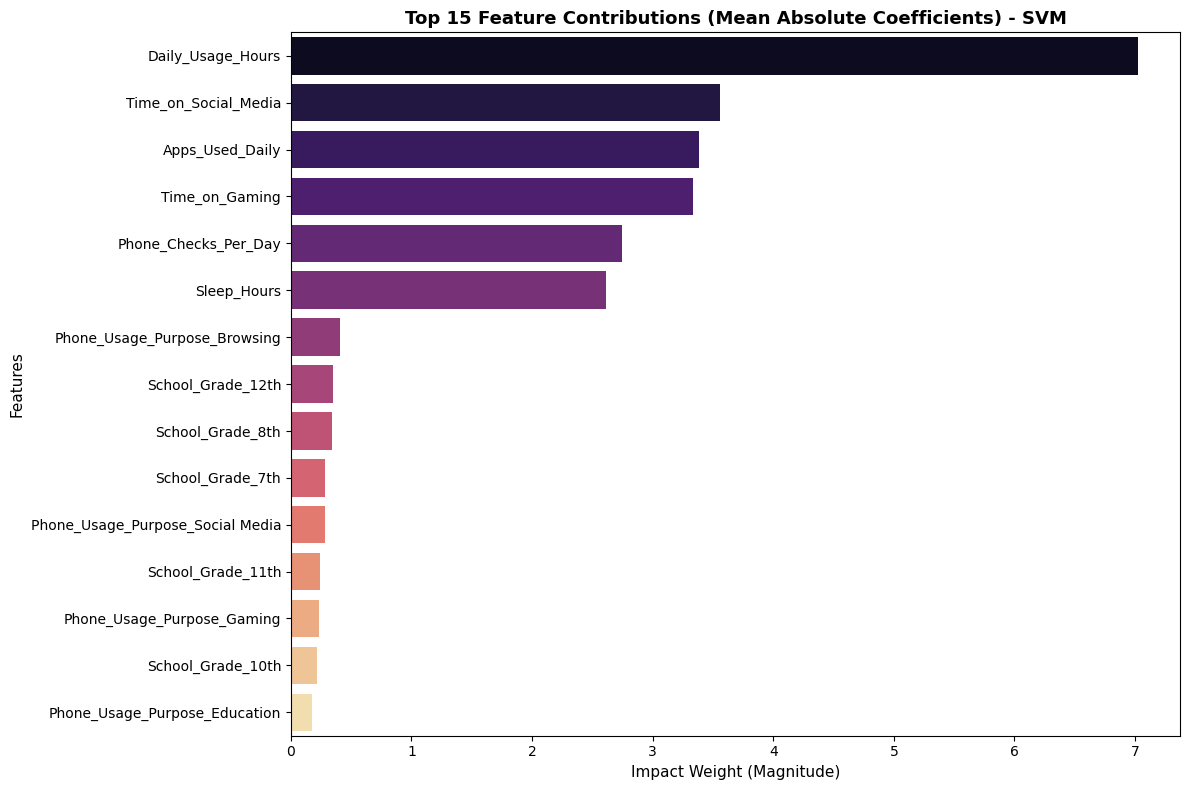

In [107]:
# 1. Dynamically retrieve the best estimator directly from your models_config dictionary
# This bypasses the undefined variable name completely
best_lr_pipeline = best_estimators['SVM']

# 2. Extract feature names from preprocessor_a
preprocessor = best_lr_pipeline.named_steps['preprocessor']

# Get encoded categorical feature names from the OneHotEncoder step
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(cat_cols).tolist()

# Combine numeric and engineered categorical columns in processing order
all_feature_names = list(num_features) + encoded_cat_features

# 3. Extract the coefficients mapping to features
lr_classifier = best_lr_pipeline.named_steps['classifier']

# Take the mean absolute coefficient value across all classes for overall importance
mean_abs_coefficients = np.mean(np.abs(lr_classifier.coef_), axis=0)

# 4. Create a DataFrame for sorting
df_lr_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Absolute Coefficient': mean_abs_coefficients
}).sort_values(by='Absolute Coefficient', ascending=False)

# 5. Plot the Top 15 Feature Contributions
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Absolute Coefficient', 
    y='Feature', 
    data=df_lr_importance.head(15), 
    palette='magma'
)
plt.title('Top 15 Feature Contributions (Mean Absolute Coefficients) - SVM', fontsize=13, fontweight='bold')
plt.xlabel('Impact Weight (Magnitude)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.tight_layout()
plt.show()

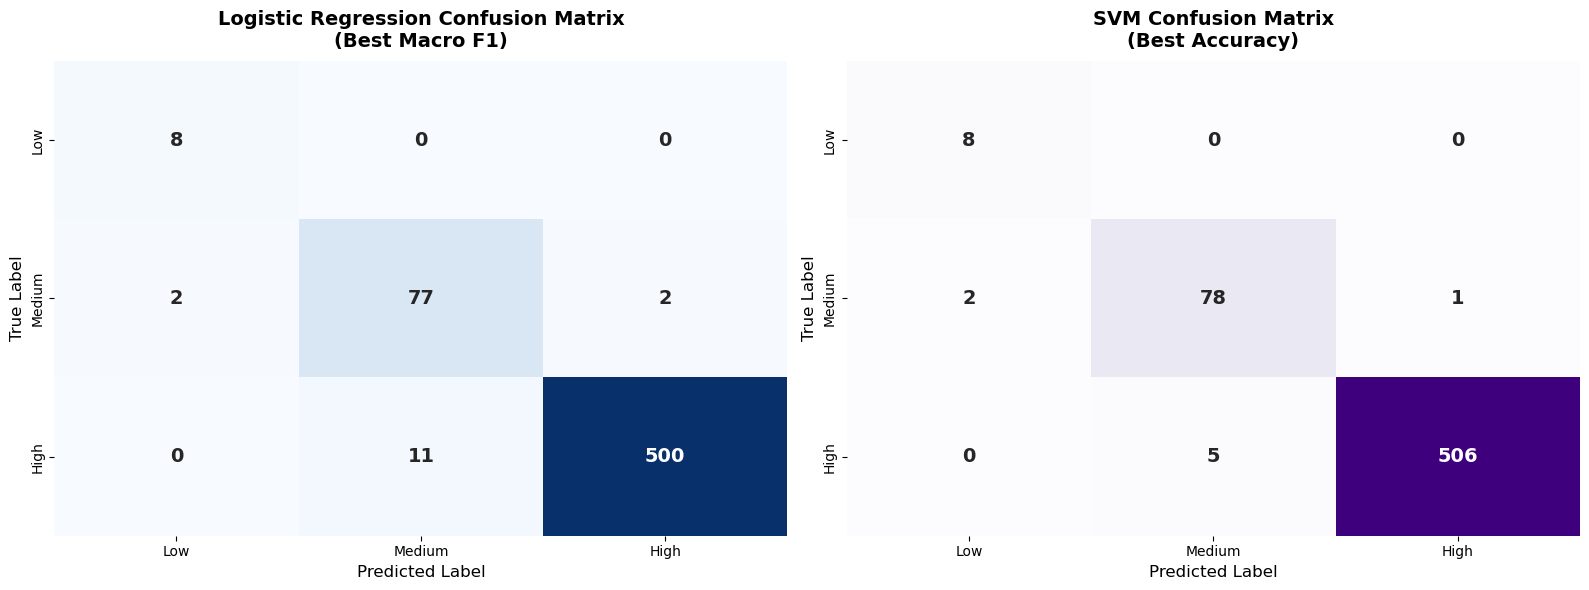

In [105]:
from sklearn.metrics import confusion_matrix

# 1. Generate predictions using the dictionary elements
best_lr = best_estimators['Logistic Regression']
best_svm = best_estimators['SVM']
y_pred_lr = best_lr.predict(X_test)
y_pred_svm = best_svm.predict(X_test)

# 2. Compute matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
target_names = ['Low', 'Medium', 'High']

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[0], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Logistic Regression Confusion Matrix\n(Best Macro F1)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', xticklabels=target_names, yticklabels=target_names, ax=axes[1], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('SVM Confusion Matrix\n(Best Accuracy)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

### Why SVM Performed the Best

Support Vector Machine (SVM) achieved the highest performance because the dataset became more balanced after applying SMOTE, allowing the model to learn clearer decision boundaries between the addiction categories. The use of feature scaling and a linear kernel helped SVM effectively handle the high-dimensional feature space created by one-hot encoding. Unlike tree-based models, SVM generalized well and maintained strong performance across both majority and minority classes, resulting in the highest accuracy (98.67%) and macro F1-score (0.9447).